# Reclustering Airway Alveolar Cells (res=0.5)

Load data

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

NEW_OBJ = "alveolar-epithelium"
NEW_OBJ_V = 'reclustered'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'sub' / NEW_OBJ / 'h5ad' / f'{NEW_OBJ}-{NEW_OBJ_V}.h5ad'

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
print(comb.obs['ann_lvl_3'].unique().tolist())

['PC_IgA', 'Fib', 'Neut', 'T', 'SMC', 'EC', 'Amb', 'Mac', 'PC_IgG', 'PC_IgAG', 'B', 'Mast', 'actFib', 'AT2', 'AlvMac', 'BC', 'AT1', 'MCC', 'PC_IgM', 'SC', 'Gob']


## Subset Airway Epithelium Types

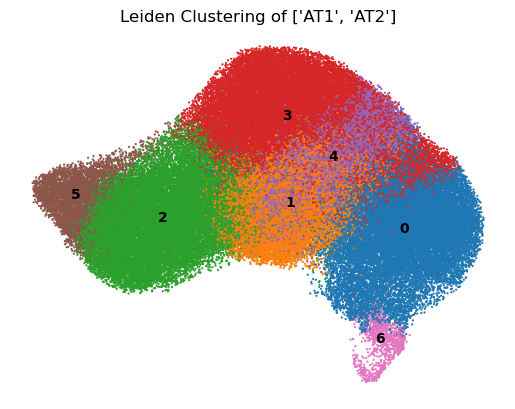

In [78]:
cts = ['AT1','AT2']

sub = comb[comb.obs["ann_lvl_3"].isin(cts)].copy()

rsc.pp.neighbors(
    sub,
    use_rep="X_resolvi",
    n_neighbors= 10,
    random_state=SEED_VALUE
)

rsc.tl.umap(
    sub,
    random_state=SEED_VALUE,
)

rsc.tl.leiden(sub, resolution=0.5, random_state=SEED_VALUE)

sc.pl.umap(sub, color=["leiden"],size=10, legend_loc="on data", frameon=False, title=f"Leiden Clustering of {cts}")

Get cluster markers

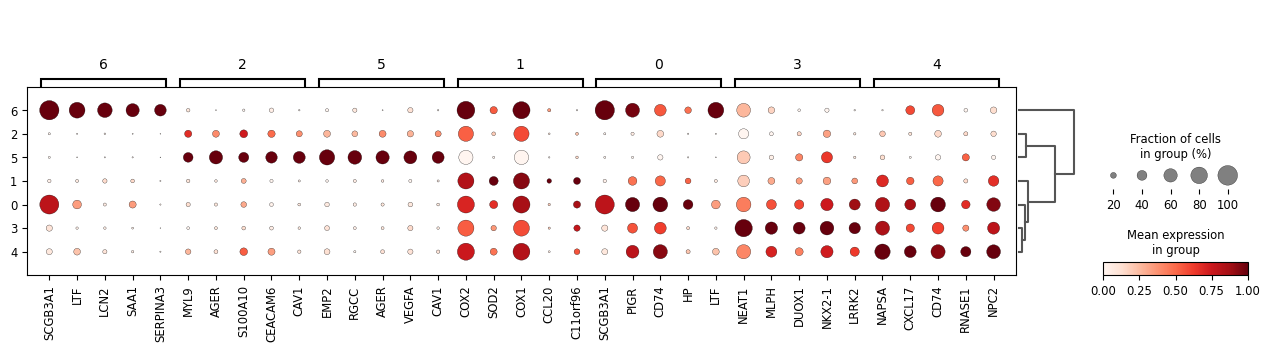

In [79]:
# get marker genes and dotplot

res_name = 'leiden'

rsc.tl.rank_genes_groups(
    sub, 
    groupby=res_name,
    method="wilcoxon",
)

sc.tl.dendrogram(sub, groupby=res_name)

# dotplot
dp = sc.pl.rank_genes_groups_dotplot(
    sub,
    groupby=res_name,
    standard_scale="var",
    n_genes=5, # normally 5 
    show=False,
    return_fig=True,   # returns a DotPlot object
)

dp.show()


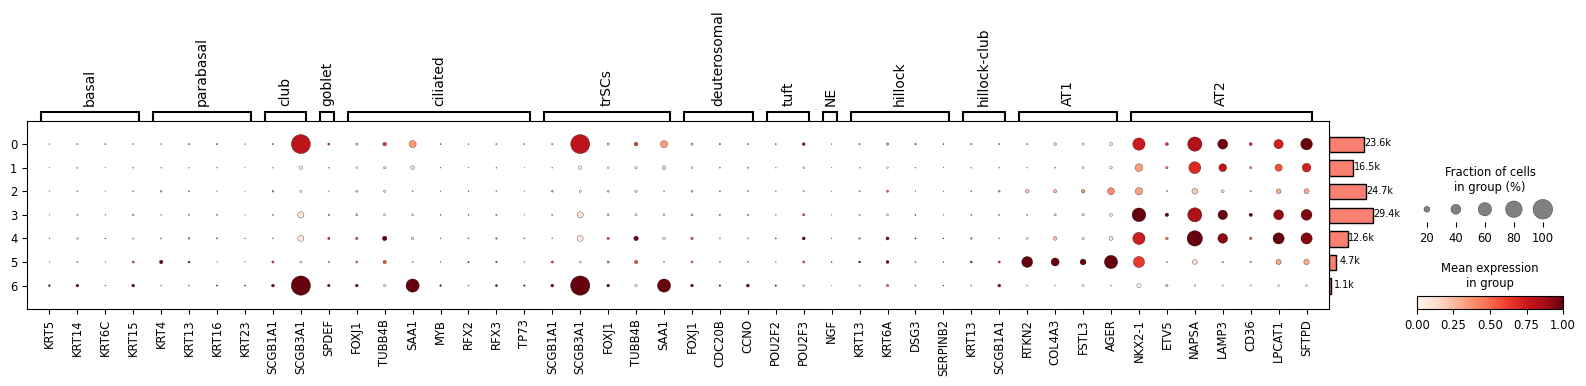

In [84]:
import json
# load canonical markers
all_markers_path = 'code/canonical_markers/epithelial_markers.json'
with open(all_markers_path, 'r') as f:
    all_markers = json.load(f)
# NOTE: check python file, some genes are suposed to be low/not expressed in some cell types

res_name = "leiden"

# all_markers = {
#     'basal': ['KRT5', 'KRT14', 'KRT15'],
#     'club': ['SCGB1A1', 'SCGB3A1'],
#     'goblet': ['SPDEF','AGR2','S100P','TFF3'],
#     'ciliated': ['FOXJ1', 'TUBB4B', 'MYB', 'RFX2', 'RFX3', 'TP73'],
#     'deuterosomal': ['FOXJ1','CDC20B', 'CCNO'],
#     'trSCs' : ['SCGB1A1', 'SCGB3A1', 'FOXJ1', 'TUBB4B'],
#     'hillock': ["KRT13","KRT6A"],
#     'SMG': ['LYZ','LTF'],
# }

dp = sc.pl.dotplot(
        sub, 
        all_markers, 
        groupby=res_name, 
        standard_scale='var', 
        #layer="resolvi_normalized",
        return_fig=True
    )
# adding cell counts to the dotplot
dp.add_totals().show()


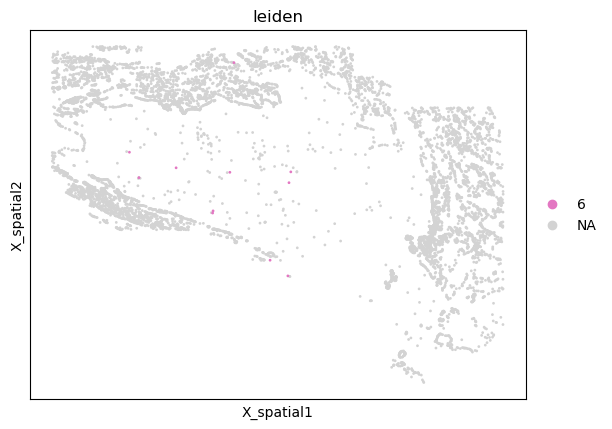

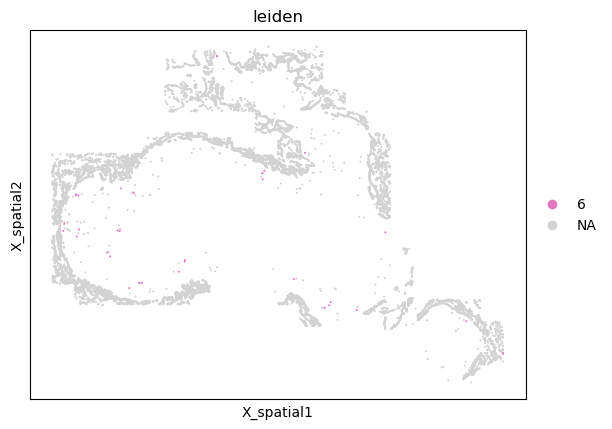

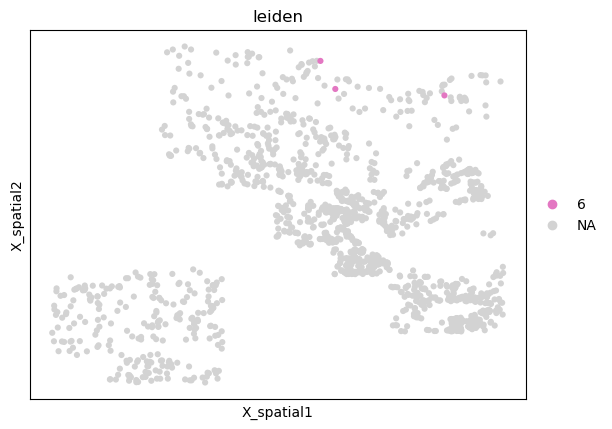

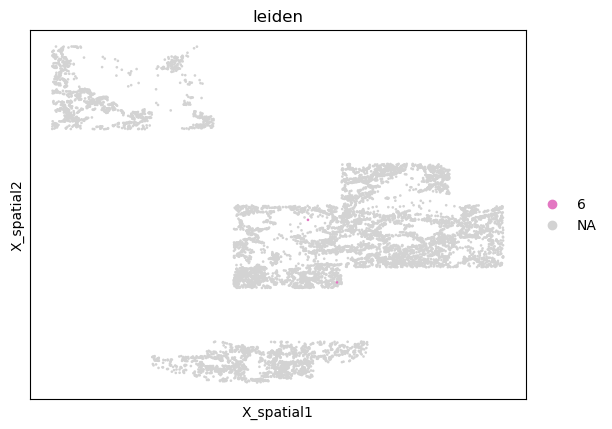

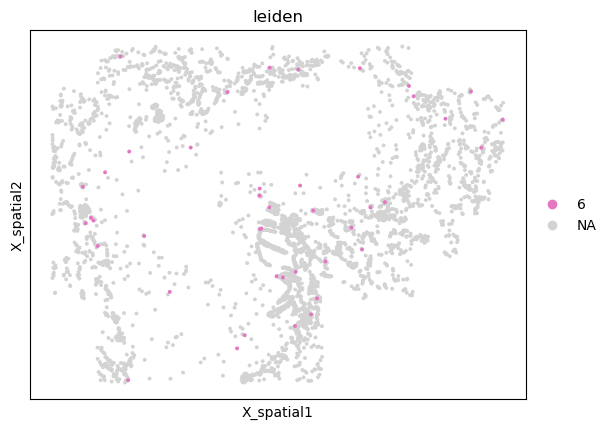

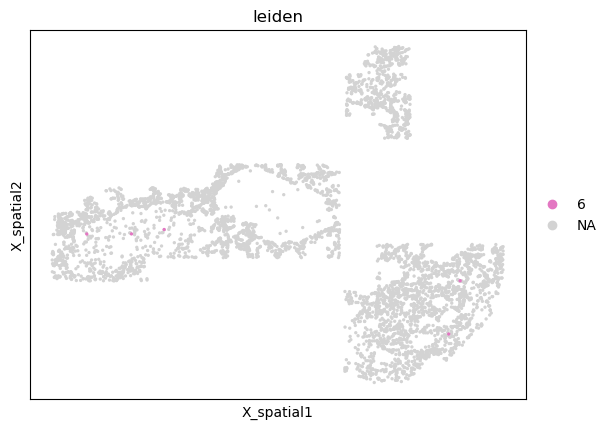

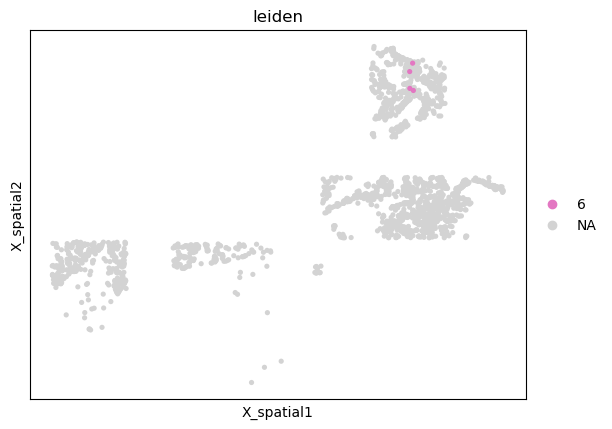

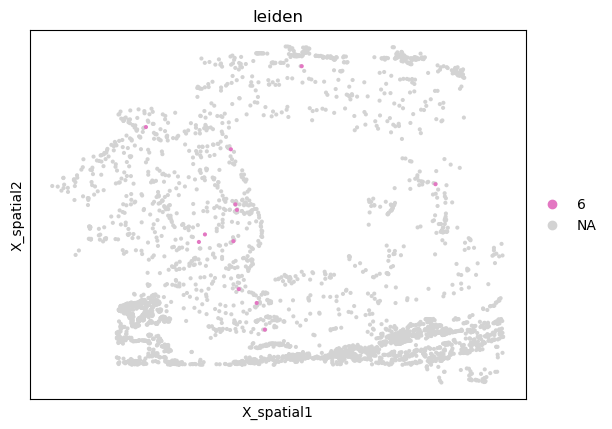

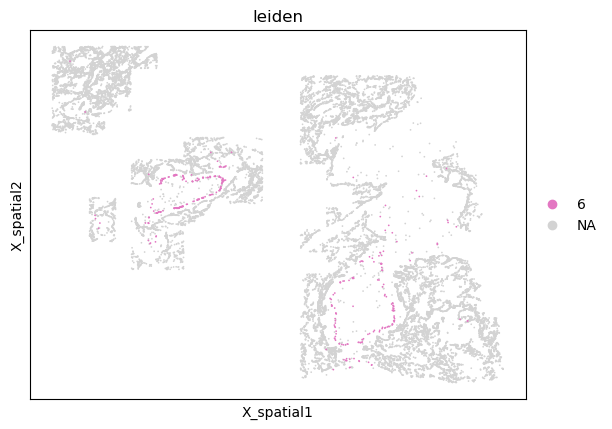

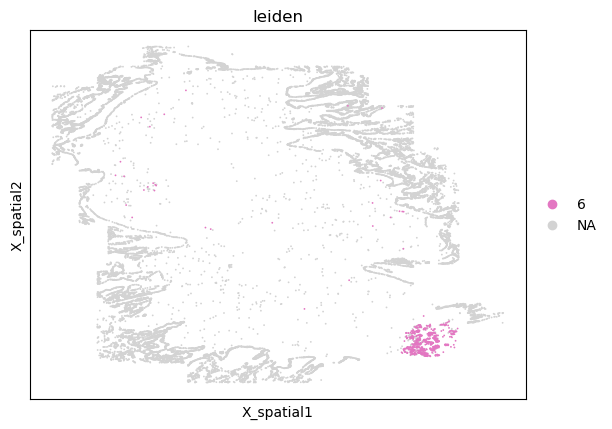

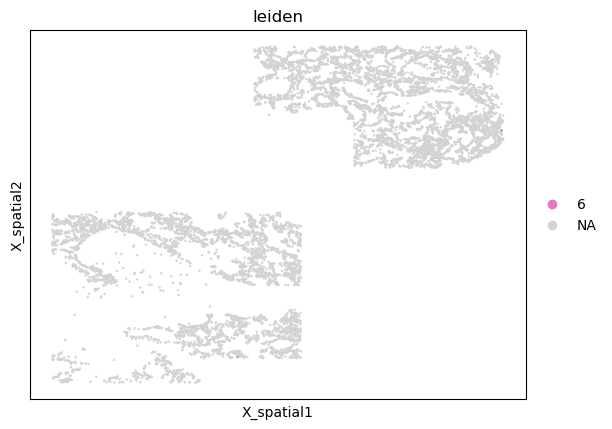

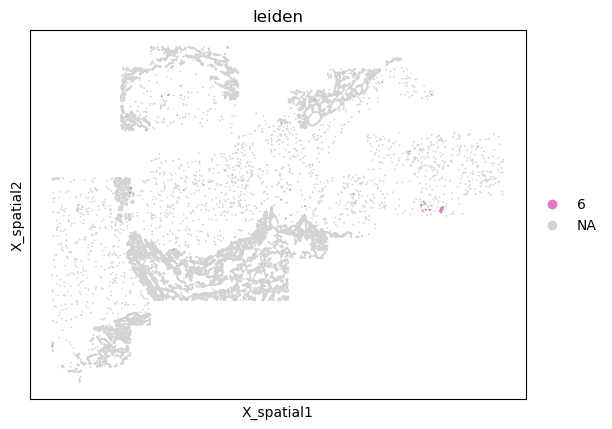

In [95]:
# check spatial location 

samples = sub.obs['sample_name'].unique()

for sample in samples:

    mask = sub.obs['sample_name'] == sample

    obj = sub[mask]

    sc.pl.embedding(
        obj,
        basis="X_spatial",
        color='leiden',
        groups='6',
        vmax='p98'
    )


In [87]:
cluster_condition_counts = pd.crosstab(
    sub.obs["leiden"],
    comb.obs["condition"]
)

cluster_condition_counts

condition,CF,CF_ETI,CTRL
leiden,,,
0,16999,5492,1089
1,8054,1420,7046
2,12270,2144,10312
3,22407,1424,5592
4,10074,530,1991
5,3289,400,1028
6,1048,54,16


Name clusters

In [6]:
sub = sc.read_h5ad(NEW_OBJ_PATH)

In [98]:
clusters_map = {
    # airway sub1thelium
    "0": "SCGB3A1_AT2", # SCGB3A1 High
    "1": "AT2",
    "2": "AT1",
    "3": "AT2",
    "4": "AT2",
    "5": "AT1",
    "6": "SMG"
}


CT_KEY = 'reclustered_ct'
CLUSTERS_KEY = 'leiden'
sub.obs[CT_KEY] = sub.obs[CLUSTERS_KEY].map(clusters_map).astype('category')

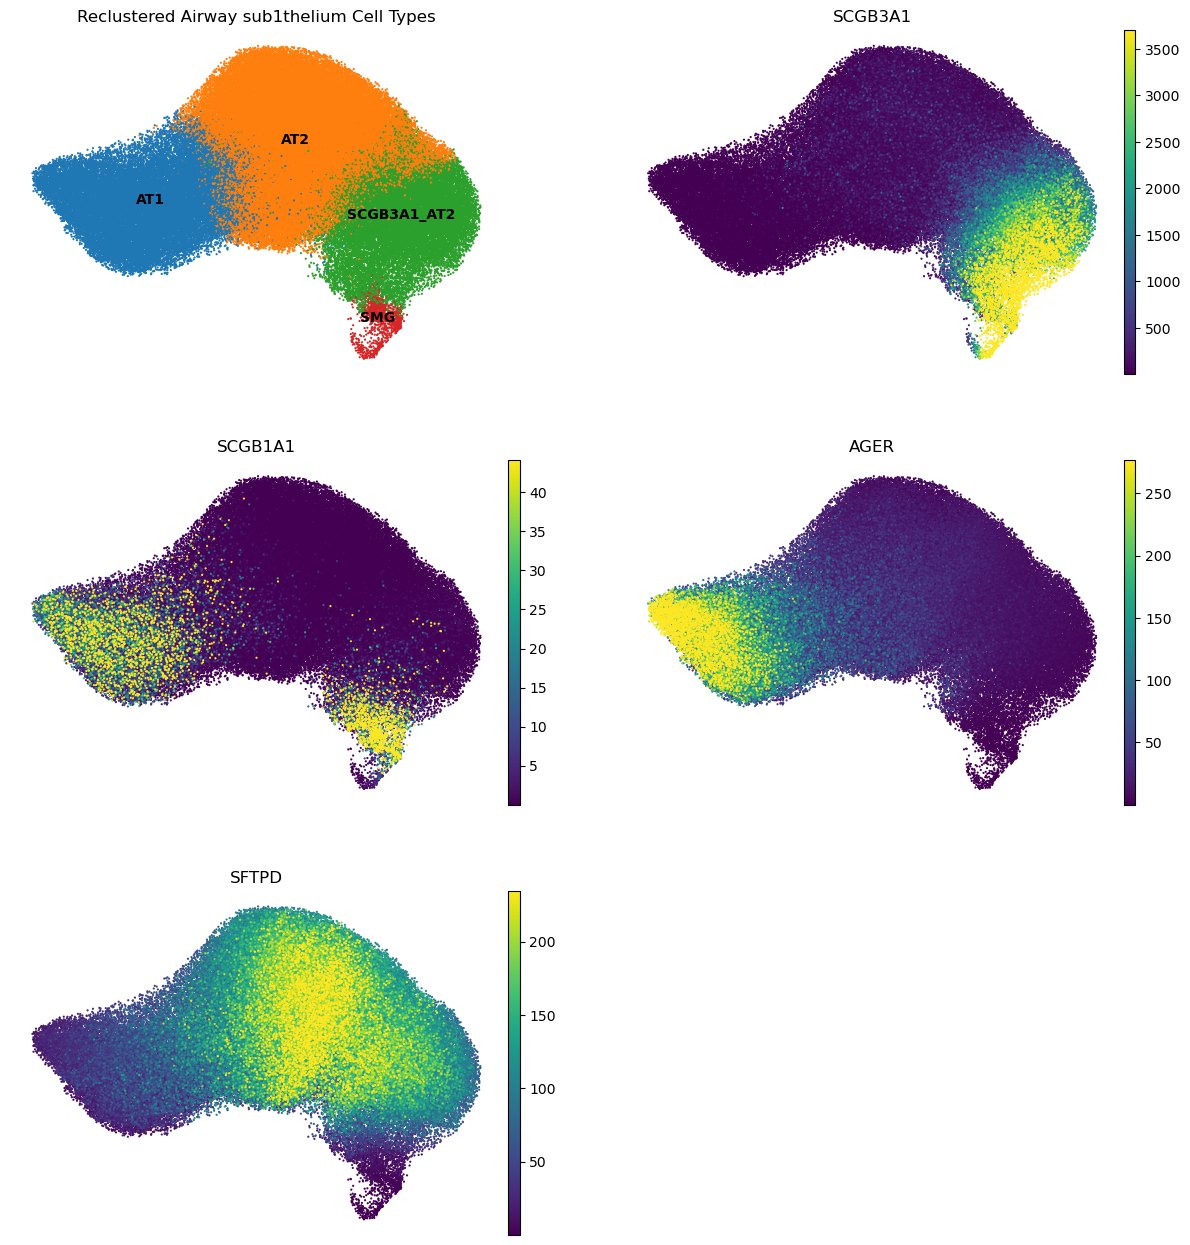

In [99]:
sc.pl.embedding(
    sub, 
    basis='X_umap',
    color=[
        CT_KEY,
        "SCGB3A1",
        "SCGB1A1",
        "AGER", # AT1
        "SFTPD" # AT2
    ], 
    size=10, 
    legend_loc="on data", 
    frameon=False, 
    title="Reclustered Airway sub1thelium Cell Types",
    layer='resolvi_normalized',
    vmax='p98',
    ncols=2
)

See how the annotations changed

In [100]:
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

OLD_ANN_KEY = 'ann_lvl_3'
NEW_ANN_KEY = 'reclustered_ct'


# Keep only cells with both values
comparison = sub.obs[[OLD_ANN_KEY, NEW_ANN_KEY]].dropna().copy()

comparison[OLD_ANN_KEY] = comparison[OLD_ANN_KEY].astype(str)
comparison[NEW_ANN_KEY] = comparison[NEW_ANN_KEY].astype(str)

# -------------------------------------------------
# 1. Composition of every Leiden cluster
# -------------------------------------------------
counts = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
)

display(counts)

# Percentage composition within each Leiden cluster
percent_within_ann = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
    normalize="index",
) * 100

display(percent_within_ann.round(1))

reclustered_ct,AT1,AT2,SCGB3A1_AT2,SMG
ann_lvl_3,,,,
AT1,22832,53,5,0
AT2,6611,58485,23575,1118


reclustered_ct,AT1,AT2,SCGB3A1_AT2,SMG
ann_lvl_3,,,,
AT1,99.7,0.2,0.0,0.0
AT2,7.4,65.1,26.3,1.2


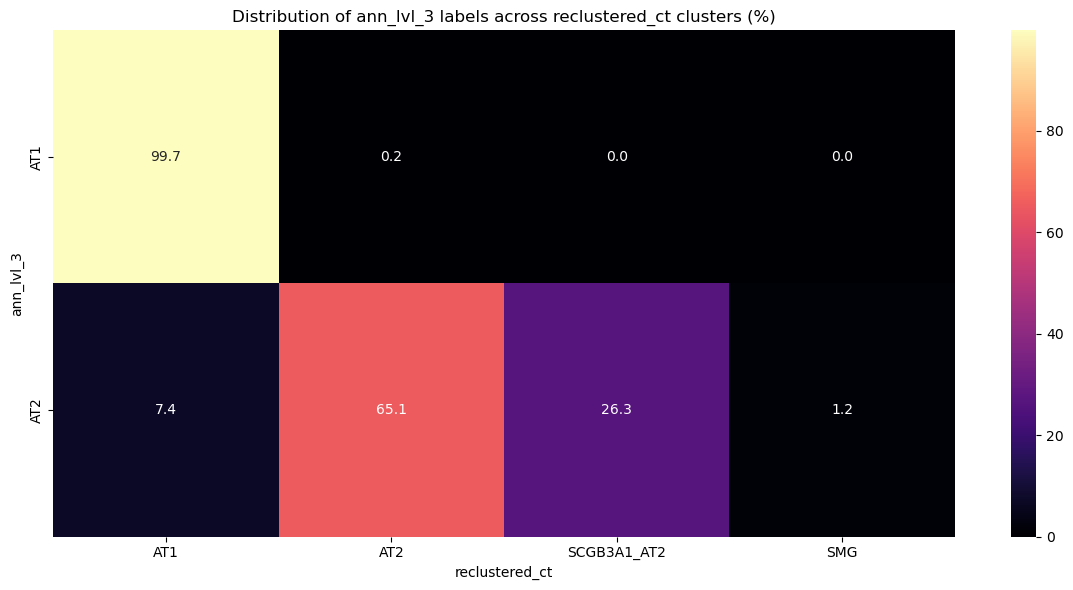

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(percent_within_ann, cmap="magma", annot=True, fmt=".1f")
plt.xlabel(NEW_ANN_KEY)
plt.ylabel(OLD_ANN_KEY)
plt.title(f"Distribution of {OLD_ANN_KEY} labels across {NEW_ANN_KEY} clusters (%)")
plt.tight_layout()
plt.show()

save object with annotations

In [102]:
NEW_OBJ_PATH.parent.mkdir(parents=True, exist_ok=True)
sub.write_h5ad(NEW_OBJ_PATH)